# Terminologia e Implementações com NetworkX — Teoria dos Grafos

Nesta versão todas as representações e algoritmos usam NetworkX. O notebook explica a terminologia e mostra exemplos executáveis e visualizações.

## Índice

- [Introdução e definições](#Introducao-e-definicoes)
- [Terminologia essencial](#Terminologia-essencial)
- [Representações com NetworkX](#Representacoes-com-NetworkX)
- [Tipos de grafos (exemplos)](#Tipos-de-grafos-(exemplos))
- [Grau e Teorema do Aperto de Mãos](#Grau-e-Teorema-do-Aperto-de-Maos)
- [Havel–Hakimi (NetworkX)](#Havel-Hakimi-(NetworkX))
- [Grafos dirigidos (in/out-degree)](#Grafos-dirigidos-(in/out-degree))
- [BFS/DFS com NetworkX](#BFS/DFS-com-NetworkX)
- [Caminhos mínimos (Dijkstra / Bellman-Ford) com NetworkX](#Caminhos-minimos-(NetworkX))
- [Eulerianidade e Problema de Königsberg](#Eulerianidade-e-Konigsberg)
- [Construção a partir de sequência de graus (Havel-Hakimi)](#Construcao-a-partir-de-sequencia)
- [Referências e exercícios](#Referencias-e-exercicios)

## Introducao e definicoes

Um grafo $G=(V,E)$ é composto de vértices $V$ e arestas $E$. A partir daqui usaremos NetworkX para representar e manipular grafos de forma eficiente.

## Terminologia essencial

- Vértice (nó)
- Aresta
- Laço, arestas paralelas (MultiGraph), grafo dirigido (DiGraph)
- Grau, in-degree, out-degree, caminho, ciclo, componente conexo, árvore

## Representacoes com NetworkX

NetworkX representa grafos com classes como `Graph`, `DiGraph` e `MultiGraph`. Abaixo mostramos operações básicas e a matriz de adjacência (se numpy estiver disponível).

In [1]:
import networkx as nx
G = nx.Graph()
G.add_edges_from([('A','B'),('A','C'),('B','C')])
print('Nodes:', list(G.nodes()))
print('Edges:', list(G.edges()))
print('Adjacency (A):', list(G.adj['A']))
print('Degree dict:', dict(G.degree()))
# Matriz de adjacencia opcional
try:
    import numpy as np
    A = nx.to_numpy_array(G, dtype=int)
    print('Adjacency matrix:\n', A)
except Exception as e:
    print('numpy não disponível ou erro ao gerar matriz:', e)

Nodes: ['A', 'B', 'C']
Edges: [('A', 'B'), ('A', 'C'), ('B', 'C')]
Adjacency (A): ['B', 'C']
Degree dict: {'A': 2, 'B': 2, 'C': 2}
Adjacency matrix:
 [[0 1 1]
 [1 0 1]
 [1 1 0]]


## Tipos de grafos (exemplos com NetworkX)

Geraremos grafos completos, ciclos, rodas e bipartidos e mostraremos visualizações.

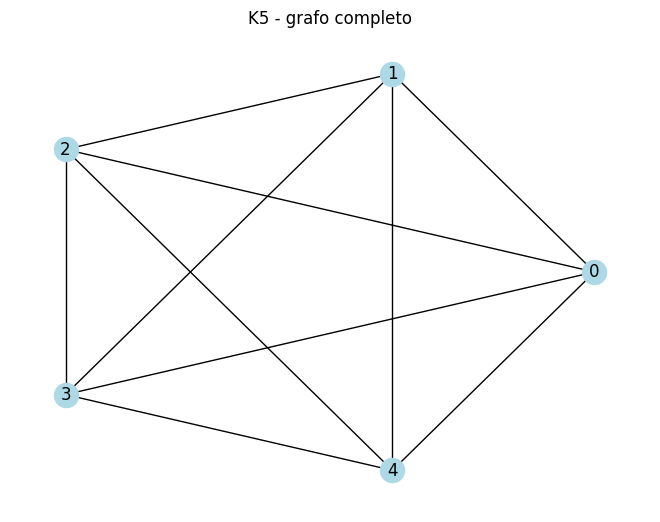

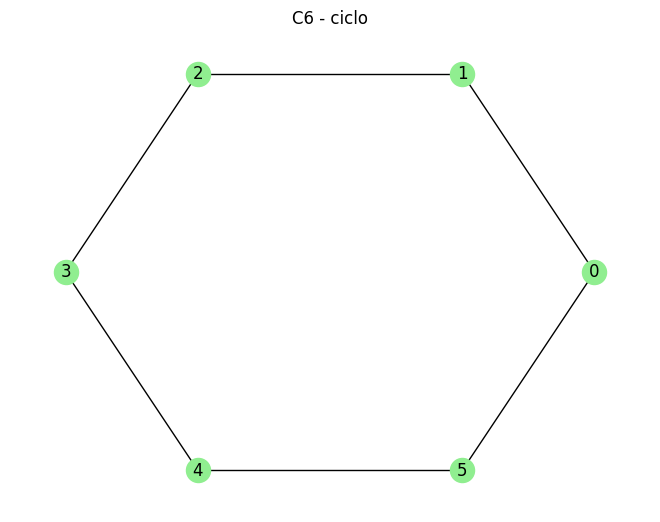

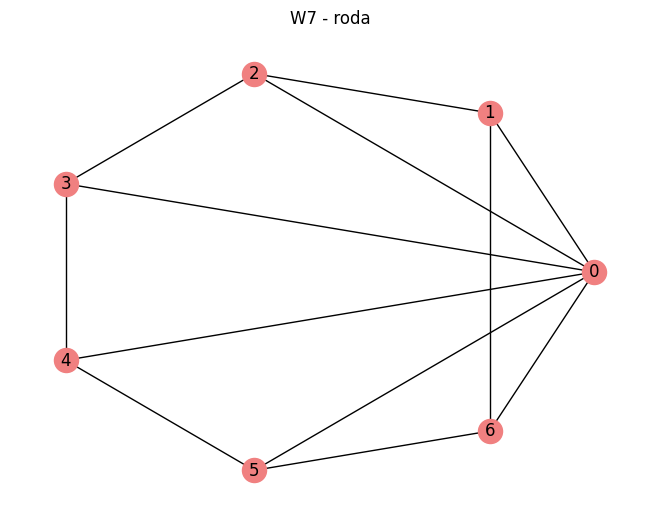

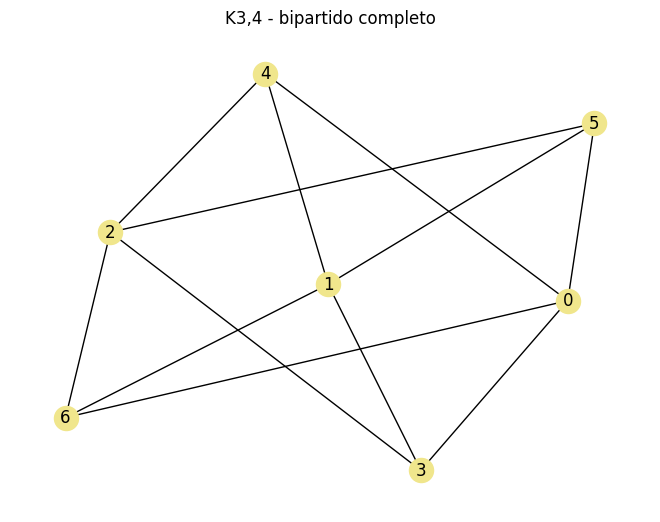

In [2]:
import matplotlib.pyplot as plt
# grafo completo K5
Gk = nx.complete_graph(5)
plt.figure()
nx.draw_circular(Gk, with_labels=True, node_color='lightblue')
plt.title('K5 - grafo completo')
plt.show()
# ciclo C6
C = nx.cycle_graph(6)
plt.figure()
nx.draw_circular(C, with_labels=True, node_color='lightgreen')
plt.title('C6 - ciclo')
plt.show()
# roda W7
W = nx.wheel_graph(7)
plt.figure()
nx.draw_circular(W, with_labels=True, node_color='lightcoral')
plt.title('W7 - roda')
plt.show()
# bipartido completo K3,4
B = nx.complete_bipartite_graph(3,4)
plt.figure()
pos = nx.spring_layout(B)
nx.draw(B, pos, with_labels=True, node_color='khaki')
plt.title('K3,4 - bipartido completo')
plt.show()

## Grau e Teorema do Aperto de Mãos

A soma dos graus dos vértices é igual a 2 vezes o número de arestas. Vamos verificar em NetworkX.

In [3]:
G = nx.path_graph(7)
degrees = dict(G.degree())
sum_degrees = sum(degrees.values())
num_edges = G.number_of_edges()
print('graus =', degrees)
print('soma dos graus =', sum_degrees)
print('2 * |E| =', 2 * num_edges)
print('Handshake verificado?', sum_degrees == 2 * num_edges)

graus = {0: 1, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 1}
soma dos graus = 12
2 * |E| = 12
Handshake verificado? True


## Havel–Hakimi (NetworkX)

NetworkX fornece utilitários para testar sequências gráficas e construir grafos Havel–Hakimi.

In [ ]:
import networkx as nx
import importlib

# Tentar importar funções do NetworkX; se não disponíveis, usar fallback local
is_graphical = None
havel_hakimi_graph = None
try:
    # tentativas diretas (várias versões do NetworkX)
    try:
        from networkx.algorithms.degree_seq import is_graphical, havel_hakimi_graph
    except Exception:
        try:
            from networkx.algorithms import degree_seq as _ds
            is_graphical = _ds.is_graphical
            havel_hakimi_graph = _ds.havel_hakimi_graph
        except Exception:
            try:
                from networkx.algorithms import degree_sequence as _ds2
                is_graphical = _ds2.is_graphical
                havel_hakimi_graph = _ds2.havel_hakimi_graph
            except Exception:
                # leave None -> implement local fallback
                pass
except Exception:
    # qualquer erro, seguir para fallback
    pass

# Implementação local simples de Havel-Hakimi (fallback se necessário)
def _is_graphical_local(seq_in):
    seq = [int(x) for x in seq_in if x > 0]
    # algoritmo Havel-Hakimi básico
    while True:
        seq.sort(reverse=True)
        if not seq:
            return True
        d = seq.pop(0)
        if d > len(seq):
            return False
        for i in range(d):
            seq[i] -= 1
            if seq[i] < 0:
                return False
        # remover zeros
        seq = [x for x in seq if x > 0]


def _havel_hakimi_graph_local(seq_in):
    seq = list(seq_in)
    n = len(seq)
    if not _is_graphical_local(seq):
        raise ValueError('sequência não é gráfica')
    G = nx.Graph()
    G.add_nodes_from(range(n))
    # trabalhar com pares (degree, node)
    deg = [(int(seq[i]), i) for i in range(n)]
    while True:
        deg.sort(key=lambda x: x[0], reverse=True)
        if deg[0][0] == 0:
            break
        d, u = deg[0]
        deg = deg[1:]
        if d > len(deg):
            raise ValueError('sequência não é gráfica (durante construção)')
        # conectar u aos próximos d nós com maior grau
        for i in range(d):
            deg[i] = (deg[i][0] - 1, deg[i][1])
            if deg[i][0] < 0:
                raise ValueError('sequência não é gráfica (decremento negativo)')
            G.add_edge(u, deg[i][1])
        # continue
    return G

# Adotar funções efetivas (NetworkX se possível, senão fallback local)
if is_graphical is None or havel_hakimi_graph is None:
    is_graphical = _is_graphical_local
    havel_hakimi_graph = _havel_hakimi_graph_local

# Exemplos
seq1 = [3,3,2,2,2]
seq2 = [4,4,4,1]
print('seq1 é gráfica? ->', is_graphical(seq1))
print('seq2 é gráfica? ->', is_graphical(seq2))
if is_graphical(seq1):
    H = havel_hakimi_graph(seq1)
    print('H edges:', list(H.edges()))
    try:
        import matplotlib.pyplot as plt
        plt.figure()
        nx.draw_spring(H, with_labels=True, node_color='lightblue')
        plt.title('Grafo Havel-Hakimi (seq1)')
        plt.show()
    except Exception:
        print('Matplotlib não disponível ou ambiente sem display — grafo criado sem plot')

ImportError: cannot import name 'degree_sequence' from 'networkx.algorithms' (d:\GitHub\DoutoradoCefet\TeoriaGrafos\.venv\Lib\site-packages\networkx\algorithms\__init__.py)

## Grafos dirigidos (in/out-degree)

Mostraremos in-degree e out-degree em um `DiGraph`.

In [ ]:
DG = nx.DiGraph()
DG.add_edges_from([(1,2),(2,3),(3,1),(3,4),(5,3)])
print('in_degree:', dict(DG.in_degree()))
print('out_degree:', dict(DG.out_degree()))
# Convertendo para não direcionado para visualização de busca
bfs_tree = nx.bfs_tree(DG.to_undirected(), source=1)
print('BFS tree (undirected view):', list(bfs_tree.edges()))

## BFS e DFS com NetworkX

NetworkX possui funções que retornam nós na ordem de busca e também árvores de busca.

In [ ]:
G_ex = nx.Graph()
G_ex.add_edges_from([('A','B'),('A','C'),('B','D'),('C','D'),('D','E')])
print('BFS order from A:', list(nx.bfs_tree(G_ex, source='A').nodes()))
print('DFS preorder from A:', list(nx.dfs_preorder_nodes(G_ex, source='A')))
bfs_tree = nx.bfs_tree(G_ex, source='A')
dfs_tree = nx.dfs_tree(G_ex, source='A')
print('BFS tree edges:', list(bfs_tree.edges()))
print('DFS tree edges:', list(dfs_tree.edges()))

## Caminhos mínimos com NetworkX

Usaremos `single_source_dijkstra` e `single_source_bellman_ford` (NetworkX) para demonstrar caminhos mínimos.

In [ ]:
Gw = nx.DiGraph()
Gw.add_weighted_edges_from([('s','a',1),('s','b',4),('a','b',2),('a','c',5),('b','c',1)])
dist_dij, paths = nx.single_source_dijkstra(Gw, source='s')
print('Dijkstra distances from s:', dist_dij)
# Bellman-Ford (NetworkX retorna comprimento e predecessores)
dist_bf, pred = nx.single_source_bellman_ford(Gw, source='s')
print('Bellman-Ford distances from s:', dist_bf)

## Eulerianidade e o problema de Königsberg

Modelaremos as sete pontes com `MultiGraph` (pois há múltiplas arestas) e verificaremos a condição de Eulerianidade.

In [ ]:
# Modelagem do problema das 7 pontes (exemplo simplificado)
G = nx.MultiGraph()
G.add_edges_from([('A','B'),('A','B'),('A','C'),('A','D'),('B','C'),('B','D'),('C','D')])
print('graus (multigraph):', dict(G.degree()))
odd = [v for v,d in G.degree() if d%2==1]
print('vertices de grau impar:', odd)
print('Existe trilha euleriana? (0 ou 2 ímpares):', len(odd) in (0,2))
# NetworkX is_eulerian funciona em Graph simples; converter- se necessário
print('is_eulerian (simple view):', nx.is_eulerian(nx.Graph(G)))

## Construção a partir de sequência de graus

NetworkX disponibiliza `havel_hakimi_graph` para construir um grafo a partir de uma sequência gráfica.

In [ ]:
import networkx as nx
import importlib

# Import robusto para funções Havel-Hakimi
is_graphical = None
havel_hakimi_graph = None
try:
    from networkx.algorithms.degree_seq import is_graphical, havel_hakimi_graph
except Exception:
    try:
        from networkx.algorithms import degree_seq as _ds
        is_graphical = _ds.is_graphical
        havel_hakimi_graph = _ds.havel_hakimi_graph
    except Exception:
        try:
            from networkx.algorithms import degree_sequence as _ds2
            is_graphical = _ds2.is_graphical
            havel_hakimi_graph = _ds2.havel_hakimi_graph
        except Exception:
            is_graphical = None
            havel_hakimi_graph = None

# Fallback local simples
def _is_graphical_local(seq_in):
    seq = [int(x) for x in seq_in if x > 0]
    while True:
        seq.sort(reverse=True)
        if not seq:
            return True
        d = seq.pop(0)
        if d > len(seq):
            return False
        for i in range(d):
            seq[i] -= 1
            if seq[i] < 0:
                return False
        seq = [x for x in seq if x > 0]


def _havel_hakimi_graph_local(seq_in):
    seq = list(seq_in)
    n = len(seq)
    if not _is_graphical_local(seq):
        raise ValueError('sequência não é gráfica')
    G = nx.Graph()
    G.add_nodes_from(range(n))
    deg = [(int(seq[i]), i) for i in range(n)]
    while True:
        deg.sort(key=lambda x: x[0], reverse=True)
        if deg[0][0] == 0:
            break
        d, u = deg[0]
        deg = deg[1:]
        if d > len(deg):
            raise ValueError('sequência não é gráfica (durante construção)')
        for i in range(d):
            deg[i] = (deg[i][0] - 1, deg[i][1])
            if deg[i][0] < 0:
                raise ValueError('sequência não é gráfica (decremento negativo)')
            G.add_edge(u, deg[i][1])
    return G

if is_graphical is None or havel_hakimi_graph is None:
    is_graphical = _is_graphical_local
    havel_hakimi_graph = _havel_hakimi_graph_local

seq = [3,3,2,2,2]
print('sequencia grafica?', is_graphical(seq, method='hh') if 'method' in getattr(is_graphical, '__code__', {}).co_varnames else is_graphical(seq))
Gseq = havel_hakimi_graph(seq)
print('nodes:', list(Gseq.nodes()))
print('edges:', list(Gseq.edges()))
import matplotlib.pyplot as plt
plt.figure()
nx.draw_spring(Gseq, with_labels=True, node_color='lightblue')
plt.title('Grafo a partir de sequência (Havel-Hakimi)')
plt.show()

## Referências e exercícios

- Cormen et al. — Introduction to Algorithms
- Diestel — Graph Theory
- Gross & Yellen — Graph Theory and Its Applications

Exercícios: aplicar Havel–Hakimi, experimentar com grafos eulerianos, implementar Kruskal e comparar com NetworkX.